# KASBench Analysis
## Download and Preprocessing

This notebook downloads the KASBench dataset from S3 and performs some basic preprocessing steps.



In [1]:
%load_ext autoreload
%autoreload 2

In [95]:
import io
import json
import os
import importlib
from __future__ import annotations
from dataclasses import dataclass


import boto3
import pandas as pd
import numpy as np
import sqlite3
import pyperclip
from dotenv import load_dotenv
import matplotlib.pyplot as plt

import common

from common import (
    get_s3_file_listing, 
    is_locust_db, 
    download_locust_db, 
    parse_locust_db_file_info,
    create_log_database,
    get_raw_log_as_dataframe,
    get_log_as_dataframe,
    get_run_details,
    get_autoscaler,
    get_trial_summary_df,
    get_autoscaler_summary,
    parse_roundtrip_file_info,
    merge_roundtrip_completion_percentage,
    calculate_theta_metrics,
    calculate_tau_metrics,
    append_time_slice,
    add_weighted_theta,
    add_weighted_tau,
    )

importlib.reload(common)


<module 'common' from '/Users/noahkrieger/projects/dissertation/kasbench/kasbench-analysis/src/common.py'>

### Get environmental variables

In [3]:
load_dotenv()
s3_bucket = os.environ.get("S3_BUCKET")
print(f"S3 Bucket: {s3_bucket}")

S3 Bucket: kasbench-test-20260528-377288663341-us-east-1-an


### Set constants and create directories

In [4]:
RUN = "exp-2026-08-02-c"
DATA_DIR = f"../data/{RUN}"
os.makedirs(DATA_DIR, exist_ok=True)
RUN_DB = f"{DATA_DIR}/logs.db"
print(f"Run database is {RUN_DB}")


Run database is ../data/exp-2026-08-02-c/logs.db


### Get the file listing from S3   

In [5]:
files = get_s3_file_listing(s3_bucket, s3_prefix=RUN)


### Iterate the file listing and download all the Locust databases to local storage

In [6]:
# Delete the log database if it already exists
if os.path.exists(RUN_DB):
    os.remove(RUN_DB)

# Create the log database
create_log_database(RUN_DB)

# Populate the log database from the locust database files
for file_info in files:
    # skip non-database files
    if not is_locust_db(file_info):
        continue
    
    # parse trial, role, and filename from the S3 file info
    trial, role, filename = parse_locust_db_file_info(file_info)

    # get the autoscaler from the run details
    run_details = get_run_details(s3_bucket, RUN, trial)
    autoscaler = get_autoscaler(run_details)

    # skip if it-operations.  It operations transactions are not tracked for response time/failure rate
    if role == "it-operations":
        continue
    
    # download the database if it doesn't already exist
    local_path = download_locust_db(DATA_DIR, s3_bucket, file_info["Key"], trial, role, filename)
    
    # load as a dataframe, augmented with run id, trial id, and role
    df = get_raw_log_as_dataframe(local_path)
    df["run_id" ] = RUN
    df["trial_id" ] = trial
    df["role" ] = role
    df["autoscaler" ] = autoscaler
    df["success"] = (
        pd.to_numeric(df["status_code"], errors="coerce")
          .between(200, 299)
        )
    df["failure"] = ~df["success"]

    # append to the sqlite database
    df.to_sql('logs', sqlite3.connect(RUN_DB), if_exists='append', index=False)
    


    


### Load the aggregate database into a dataframe for analysis

In [7]:
df = get_log_as_dataframe(RUN_DB)
raw_df = df.copy()
df

,run_id,trial_id,role,autoscaler,user_id,request_type,name,response_time,response_length,response,status_code,reason,exception,start_time,url,method_and_name,success,failure
0,exp-2026-08-02-c,trial0001,back-office,vpa,c66465d0-d110-477c-8b57-5774d4b43bb7,POST,/api/portfolios/bulk,37.952766,140,<Response [201]>,201,Created,None,2026-08-02 16:10:50.149567,http://kasb-20260802155403297400000014-b2f3dc0...,POST /api/portfolios/bulk,1,0
1,exp-2026-08-02-c,trial0001,back-office,vpa,57a15a67-4cf1-40ab-93a4-501a120369da,GET,/api/portfolios/{id},29.993266,133,<Response [200]>,200,OK,None,2026-08-02 16:10:55.388726,http://kasb-20260802155403297400000014-b2f3dc0...,GET /api/portfolios/{id},1,0
2,exp-2026-08-02-c,trial0001,back-office,vpa,c66465d0-d110-477c-8b57-5774d4b43bb7,GET,/api/portfolios/{id},19.078246,133,<Response [200]>,200,OK,None,2026-08-02 16:10:56.047427,http://kasb-20260802155403297400000014-b2f3dc0...,GET /api/portfolios/{id},1,0
3,exp-2026-08-02-c,trial0001,back-office,vpa,6f30fe02-1471-407b-8d1b-c595820215fd,POST,/api/portfolios/bulk,25.788154,140,<Response [201]>,201,Created,None,2026-08-02 16:10:56.638008,http://kasb-20260802155403297400000014-b2f3dc0...,POST /api/portfolios/bulk,1,0
4,exp-2026-08-02-c,trial0001,back-office,vpa,48c703ae-ad00-4893-9724-d40ba747dda9,GET,/api/portfolios/{id},22.076400,133,<Response [200]>,200,OK,None,2026-08-02 16:10:58.535957,http://kasb-20260802155403297400000014-b2f3dc0...,GET /api/portfolios/{id},1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234114,exp-2026-08-02-c,trial0012,trader,hpa,2569a186-c143-47ff-b52c-90aefa84a63b,POST,/api/trade-orders/batch/submit,29.189712,1044,<Response [200]>,200,OK,None,2026-08-03 00:49:57.041504,http://kasb-20260803002024141500000014-977014f...,POST /api/trade-orders/batch/submit,1,0
234115,exp-2026-08-02-c,trial0012,trader,hpa,8a1c4ee5-a54f-424e-99c4-4b80024a60ba,GET,/api/trades?orderId,13.796214,622,<Response [200]>,200,OK,None,2026-08-03 00:50:04.550745,http://kasb-20260803002024141500000014-977014f...,GET /api/trades?orderId,1,0
234116,exp-2026-08-02-c,trial0012,trader,hpa,8a1c4ee5-a54f-424e-99c4-4b80024a60ba,POST,/api/trade-orders/batch/submit,34.278593,1045,<Response [200]>,200,OK,None,2026-08-03 00:50:04.570462,http://kasb-20260803002024141500000014-977014f...,POST /api/trade-orders/batch/submit,1,0
234117,exp-2026-08-02-c,trial0012,trader,hpa,8a1c4ee5-a54f-424e-99c4-4b80024a60ba,GET,/api/trades?orderId,24.098116,624,<Response [200]>,200,OK,None,2026-08-03 00:50:05.332916,http://kasb-20260803002024141500000014-977014f...,GET /api/trades?orderId,1,0


### Summarize the trials

In [8]:
trial_summary_df = get_trial_summary_df(df)
trial_summary_df

,autoscaler,trial_id,requests,mean_response_time,failures,failure_rate
0,hpa,trial0008,19261,2067.239654,412,0.021390
1,hpa,trial0012,21680,245.180317,15,0.000692
2,keda,trial0003,22299,203.104362,32,0.001435
3,keda,trial0005,22125,198.235355,33,0.001492
4,keda,trial0007,22585,718.315986,442,0.019571
5,none,trial0004,21447,359.395990,30,0.001399
6,none,trial0006,15843,4333.210904,2220,0.140125
7,none,trial0009,18127,3309.908008,882,0.048657
8,none,trial0011,16445,4172.390502,3425,0.208270
9,vpa,trial0001,20160,943.266149,1050,0.052083


### Merge Roundtrip Percentage

In [9]:
merged_trial_summary_df = merge_roundtrip_completion_percentage(files, s3_bucket, trial_summary_df)
merged_trial_summary_df


,autoscaler,trial_id,requests,mean_response_time,failures,failure_rate,quantity_ordered,quantity_placed,quantity_filled,roundtrip_completion_percentage
0,hpa,trial0008,19261,2067.239654,412,0.021390,7743696,7743696,719444,9.290706
1,hpa,trial0012,21680,245.180317,15,0.000692,7202477,7202477,644967,8.954794
2,keda,trial0003,22299,203.104362,32,0.001435,6957005,6957005,1141738,16.411344
3,keda,trial0005,22125,198.235355,33,0.001492,9403975,9403975,1460188,15.527349
4,keda,trial0007,22585,718.315986,442,0.019571,8530134,8530134,1376311,16.134694
5,none,trial0004,21447,359.395990,30,0.001399,6081593,6081593,605877,9.962472
6,none,trial0006,15843,4333.210904,2220,0.140125,3996477,3996477,558393,13.972131
7,none,trial0009,18127,3309.908008,882,0.048657,5221906,5221906,646808,12.386435
8,none,trial0011,16445,4172.390502,3425,0.208270,3691791,3691791,743930,20.150924
9,vpa,trial0001,20160,943.266149,1050,0.052083,8299650,8299650,860898,10.372702


In [10]:
merged_trial_summary_df.columns

Index(['autoscaler', 'trial_id', 'requests', 'mean_response_time', 'failures',
       'failure_rate', 'quantity_ordered', 'quantity_placed',
       'quantity_filled', 'roundtrip_completion_percentage'],
      dtype='str')

### Aggregate the summarized trials

In [11]:
autoscaler_summary = get_autoscaler_summary(merged_trial_summary_df)
autoscaler_summary

,autoscaler,trials,mean_rt,median_rt,sd_rt,mean_failure_rate,median_failure_rate,sd_failure_rate,mean_roundtrip_completion_percentage,median_roundtrip_completion_percentage,sd_roundtrip_completion_percentage,total_quantity_ordered,total_quantity_placed,total_quantity_filled,ci95_rt,ci95_failure_rate,ci95_roundtrip_completion_percentage,pooled_roundtrip_completion_percentage
0,hpa,2,1156.209985,1156.209985,1288.390513,0.011041,0.011041,0.014636,9.122750,9.122750,0.237525,14946173,14946173,1364411,11575.729488,0.131500,2.134079,9.128832
1,keda,3,373.218568,203.104362,298.873046,0.007499,0.001492,0.010454,16.024462,16.134694,0.452189,24891114,24891114,3978237,742.441805,0.025970,1.123300,15.982559
2,none,4,3043.726351,3741.149255,1845.095783,0.099613,0.094391,0.092539,14.117991,13.179283,4.346806,18991767,18991767,2555008,2935.959128,0.147249,6.916739,13.453240
3,vpa,3,3428.250715,2365.336928,3153.768914,0.134267,0.083741,0.116015,15.255629,12.470408,6.723129,19555001,19555001,2622404,7834.396293,0.288198,16.701179,13.410401


### Visualize the results

#### Plot mean response time by autoscaler


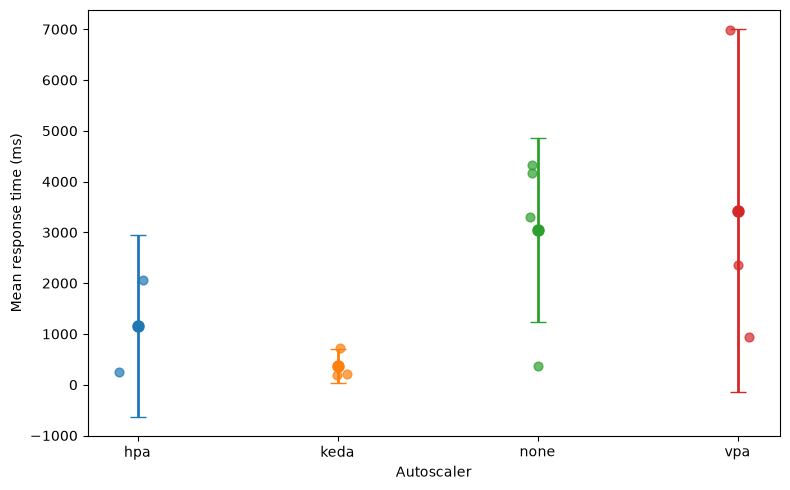

In [12]:
fig, ax = plt.subplots(figsize=(8,5))

autoscalers = sorted(merged_trial_summary_df["autoscaler"].unique())

for i, a in enumerate(autoscalers):
    d = trial_summary_df[trial_summary_df.autoscaler == a]

    # jittered trial means
    x = np.random.normal(i, 0.04, len(d))
    ax.scatter(x, d["mean_response_time"],
               alpha=0.7, s=40)

    mean = d["mean_response_time"].mean()
    se = d["mean_response_time"].std(ddof=1) / np.sqrt(len(d))

    ax.errorbar(
        i,
        mean,
        yerr=1.96 * se,
        fmt="o",
        capsize=6,
        markersize=8,
        linewidth=2,
    )

ax.set_xticks(range(len(autoscalers)))
ax.set_xticklabels(autoscalers)
ax.set_ylabel("Mean response time (ms)")
ax.set_xlabel("Autoscaler")

plt.tight_layout()

In [13]:
fig.savefig(
    "../figures/response_time_by_autoscaler.png",
    dpi=300,
    bbox_inches="tight",
)

#### Plot failure rate by autoscaler


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t


def plot_failure_rate_by_autoscaler(
    trial_summary: pd.DataFrame,
    *,
    autoscaler_order: list[str] | None = None,
    confidence_level: float = 0.95,
    random_seed: int = 42,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot trial-level failure rates by autoscaler.

    Each small point represents one trial. The larger point represents the
    unweighted mean of the trial failure rates. Error bars show a two-sided
    Student-t confidence interval for the mean.

    Parameters
    ----------
    trial_summary:
        DataFrame containing:
          - autoscaler
          - trial_id
          - failure_rate

        failure_rate must be expressed as a proportion, e.g. 0.025 for 2.5%.

    autoscaler_order:
        Optional display order. Autoscalers not listed here are appended
        alphabetically.

    confidence_level:
        Confidence level for the error bars. Default is 0.95.

    random_seed:
        Seed used to make horizontal point jitter reproducible.

    Returns
    -------
    tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]
        The generated figure and axes.
    """
    required_columns = {"autoscaler", "trial_id", "failure_rate"}
    missing_columns = required_columns - set(trial_summary.columns)

    if missing_columns:
        raise ValueError(
            f"trial_summary is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if not 0 < confidence_level < 1:
        raise ValueError("confidence_level must be between 0 and 1.")

    plot_df = trial_summary[
        ["autoscaler", "trial_id", "failure_rate"]
    ].copy()

    plot_df["failure_rate"] = pd.to_numeric(
        plot_df["failure_rate"],
        errors="coerce",
    )

    if plot_df["failure_rate"].isna().any():
        bad_rows = plot_df.loc[plot_df["failure_rate"].isna()]
        raise ValueError(
            "failure_rate contains missing or nonnumeric values. "
            f"Invalid rows:\n{bad_rows}"
        )

    if not plot_df["failure_rate"].between(0, 1).all():
        bad_rows = plot_df.loc[
            ~plot_df["failure_rate"].between(0, 1)
        ]
        raise ValueError(
            "failure_rate must be between 0 and 1. "
            f"Invalid rows:\n{bad_rows}"
        )

    present_autoscalers = sorted(
        plot_df["autoscaler"].dropna().unique()
    )

    if autoscaler_order is None:
        autoscalers = present_autoscalers
    else:
        autoscalers = [
            autoscaler
            for autoscaler in autoscaler_order
            if autoscaler in present_autoscalers
        ]

        autoscalers.extend(
            autoscaler
            for autoscaler in present_autoscalers
            if autoscaler not in autoscalers
        )

    rng = np.random.default_rng(random_seed)

    fig, ax = plt.subplots(figsize=(8, 5.5))

    alpha = 1 - confidence_level
    summary_rows = []

    for position, autoscaler in enumerate(autoscalers):
        autoscaler_df = plot_df.loc[
            plot_df["autoscaler"] == autoscaler
        ]

        rates_percent = (
            autoscaler_df["failure_rate"].to_numpy() * 100
        )

        # Add slight horizontal jitter so overlapping trial points remain visible.
        jittered_x = rng.normal(
            loc=position,
            scale=0.045,
            size=len(rates_percent),
        )

        ax.scatter(
            jittered_x,
            rates_percent,
            s=45,
            alpha=0.65,
            label="Individual trial" if position == 0 else None,
            zorder=2,
        )

        number_of_trials = len(rates_percent)
        mean_rate = rates_percent.mean()

        if number_of_trials >= 2:
            standard_deviation = rates_percent.std(ddof=1)
            standard_error = (
                standard_deviation / np.sqrt(number_of_trials)
            )

            critical_value = t.ppf(
                1 - alpha / 2,
                df=number_of_trials - 1,
            )

            confidence_interval_half_width = (
                critical_value * standard_error
            )
        else:
            standard_deviation = np.nan
            standard_error = np.nan
            confidence_interval_half_width = np.nan

        ax.errorbar(
            position,
            mean_rate,
            yerr=confidence_interval_half_width,
            fmt="o",
            markersize=9,
            capsize=7,
            capthick=1.5,
            linewidth=2,
            label=(
                f"Mean and {confidence_level:.0%} CI"
                if position == 0
                else None
            ),
            zorder=3,
        )

        summary_rows.append(
            {
                "autoscaler": autoscaler,
                "trials": number_of_trials,
                "mean_failure_rate": mean_rate / 100,
                "sd_failure_rate": standard_deviation / 100,
                "se_failure_rate": standard_error / 100,
                "ci_lower": (
                    max(
                        0,
                        mean_rate
                        - confidence_interval_half_width,
                    )
                    / 100
                    if number_of_trials >= 2
                    else np.nan
                ),
                "ci_upper": (
                    min(
                        100,
                        mean_rate
                        + confidence_interval_half_width,
                    )
                    / 100
                    if number_of_trials >= 2
                    else np.nan
                ),
            }
        )

    ax.set_xticks(range(len(autoscalers)))
    ax.set_xticklabels(
        [autoscaler.upper() for autoscaler in autoscalers]
    )

    ax.set_xlabel("Autoscaler")
    ax.set_ylabel("Failure rate (%)")
    ax.set_title(
        "Failure Rate by Autoscaler\n"
        "Trial-level rates with mean and "
        f"{confidence_level:.0%} confidence interval"
    )

    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

    fig.tight_layout()

    # The summary can be retrieved from the axes for later use if desired.
    ax.failure_rate_summary = pd.DataFrame(summary_rows)

    return fig, ax

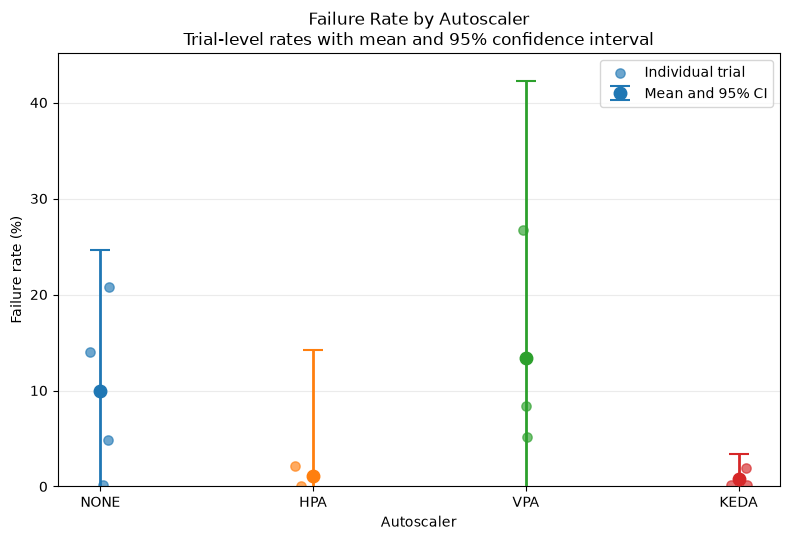

In [15]:
fig, ax = plot_failure_rate_by_autoscaler(
    merged_trial_summary_df,
    autoscaler_order=["none", "hpa", "vpa", "keda"],
)

plt.show()

In [16]:
fig.savefig(
    "../figures/failure_rate_by_autoscaler.png",
    dpi=300,
    bbox_inches="tight",
)

#### Plot of roundtrip completion percentage by autoscaler

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t


def plot_roundtrip_completion_by_autoscaler(
    trial_summary: pd.DataFrame,
    *,
    autoscaler_order: list[str] | None = None,
    confidence_level: float = 0.95,
    random_seed: int = 42,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot trial-level round-trip completion percentages by autoscaler.

    Each small point represents one trial. The larger point represents the
    unweighted mean of the trial percentages. Error bars show a two-sided
    Student-t confidence interval for the mean.

    Parameters
    ----------
    trial_summary:
        DataFrame containing:
          - autoscaler
          - trial_id
          - roundtrip_completion_percentage

        roundtrip_completion_percentage must be expressed in percentage
        points, such as 9.3 for 9.3%, rather than 0.093.

    autoscaler_order:
        Optional display order. Autoscalers present in the dataframe but not
        listed here are appended alphabetically.

    confidence_level:
        Confidence level for the error bars. Defaults to 0.95.

    random_seed:
        Seed used to make the horizontal jitter reproducible.

    Returns
    -------
    tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]
        The generated figure and axes.
    """
    required_columns = {
        "autoscaler",
        "trial_id",
        "roundtrip_completion_percentage",
    }
    missing_columns = required_columns - set(trial_summary.columns)

    if missing_columns:
        raise ValueError(
            "trial_summary is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if not 0 < confidence_level < 1:
        raise ValueError("confidence_level must be between 0 and 1.")

    plot_df = trial_summary[
        [
            "autoscaler",
            "trial_id",
            "roundtrip_completion_percentage",
        ]
    ].copy()

    if plot_df["autoscaler"].isna().any():
        raise ValueError("autoscaler contains missing values.")

    if plot_df["trial_id"].isna().any():
        raise ValueError("trial_id contains missing values.")

    plot_df["roundtrip_completion_percentage"] = pd.to_numeric(
        plot_df["roundtrip_completion_percentage"],
        errors="coerce",
    )

    if plot_df["roundtrip_completion_percentage"].isna().any():
        bad_rows = plot_df.loc[
            plot_df["roundtrip_completion_percentage"].isna()
        ]
        raise ValueError(
            "roundtrip_completion_percentage contains missing or "
            f"nonnumeric values:\n{bad_rows}"
        )

    if not plot_df["roundtrip_completion_percentage"].between(
        0, 100
    ).all():
        bad_rows = plot_df.loc[
            ~plot_df["roundtrip_completion_percentage"].between(0, 100)
        ]
        raise ValueError(
            "roundtrip_completion_percentage must be between 0 and 100. "
            f"Invalid rows:\n{bad_rows}"
        )

    # Prevent a trial from being counted more than once for an autoscaler.
    duplicate_mask = plot_df.duplicated(
        subset=["autoscaler", "trial_id"],
        keep=False,
    )

    if duplicate_mask.any():
        duplicate_rows = plot_df.loc[
            duplicate_mask,
            ["autoscaler", "trial_id"],
        ].sort_values(["autoscaler", "trial_id"])

        raise ValueError(
            "Each autoscaler/trial_id combination must appear exactly once. "
            f"Duplicate rows:\n{duplicate_rows}"
        )

    present_autoscalers = sorted(
        plot_df["autoscaler"].astype(str).unique()
    )

    if autoscaler_order is None:
        autoscalers = present_autoscalers
    else:
        autoscalers = [
            autoscaler
            for autoscaler in autoscaler_order
            if autoscaler in present_autoscalers
        ]

        autoscalers.extend(
            autoscaler
            for autoscaler in present_autoscalers
            if autoscaler not in autoscalers
        )

    if not autoscalers:
        raise ValueError("No autoscaler data is available to plot.")

    rng = np.random.default_rng(random_seed)
    alpha = 1 - confidence_level

    fig, ax = plt.subplots(figsize=(8, 5.5))

    summary_rows: list[dict[str, float | int | str]] = []

    for position, autoscaler in enumerate(autoscalers):
        autoscaler_df = plot_df.loc[
            plot_df["autoscaler"] == autoscaler
        ].sort_values("trial_id")

        percentages = autoscaler_df[
            "roundtrip_completion_percentage"
        ].to_numpy(dtype=float)

        number_of_trials = len(percentages)

        # Slight horizontal jitter keeps overlapping trial points visible.
        jittered_x = rng.normal(
            loc=position,
            scale=0.045,
            size=number_of_trials,
        )

        ax.scatter(
            jittered_x,
            percentages,
            s=45,
            alpha=0.65,
            label="Individual trial" if position == 0 else None,
            zorder=2,
        )

        mean_percentage = percentages.mean()

        if number_of_trials >= 2:
            standard_deviation = percentages.std(ddof=1)
            standard_error = (
                standard_deviation / np.sqrt(number_of_trials)
            )

            critical_value = t.ppf(
                1 - alpha / 2,
                df=number_of_trials - 1,
            )

            confidence_interval_half_width = (
                critical_value * standard_error
            )

            confidence_interval_lower = max(
                0.0,
                mean_percentage - confidence_interval_half_width,
            )
            confidence_interval_upper = min(
                100.0,
                mean_percentage + confidence_interval_half_width,
            )

            # Asymmetric errors allow confidence bounds to be clipped to
            # the logically valid 0%-100% interval.
            lower_error = mean_percentage - confidence_interval_lower
            upper_error = confidence_interval_upper - mean_percentage
            yerr = np.array([[lower_error], [upper_error]])
        else:
            standard_deviation = np.nan
            standard_error = np.nan
            critical_value = np.nan
            confidence_interval_half_width = np.nan
            confidence_interval_lower = np.nan
            confidence_interval_upper = np.nan
            yerr = None

        ax.errorbar(
            position,
            mean_percentage,
            yerr=yerr,
            fmt="o",
            markersize=9,
            capsize=7,
            capthick=1.5,
            linewidth=2,
            label=(
                f"Mean and {confidence_level:.0%} CI"
                if position == 0
                else None
            ),
            zorder=3,
        )

        summary_rows.append(
            {
                "autoscaler": autoscaler,
                "trials": number_of_trials,
                "mean_roundtrip_completion_percentage": mean_percentage,
                "sd_roundtrip_completion_percentage": standard_deviation,
                "se_roundtrip_completion_percentage": standard_error,
                "t_critical": critical_value,
                "ci_half_width": confidence_interval_half_width,
                "ci_lower": confidence_interval_lower,
                "ci_upper": confidence_interval_upper,
            }
        )

    ax.set_xticks(range(len(autoscalers)))
    ax.set_xticklabels(
        [autoscaler.upper() for autoscaler in autoscalers]
    )

    ax.set_xlabel("Autoscaler")
    ax.set_ylabel("Round-trip completion percentage (%)")
    ax.set_title(
        "Round-Trip Completion by Autoscaler\n"
        "Trial-level percentages with mean and "
        f"{confidence_level:.0%} confidence interval"
    )

    # Start at zero because the metric has a meaningful zero.
    # Let Matplotlib choose the upper bound unless the values approach 100%.
    ax.set_ylim(bottom=0)

    ax.grid(
        axis="y",
        alpha=0.25,
    )
    ax.legend()

    fig.tight_layout()

    # Attach the statistics used in the chart for convenient retrieval.
    ax.roundtrip_completion_summary = pd.DataFrame(summary_rows)

    return fig, ax

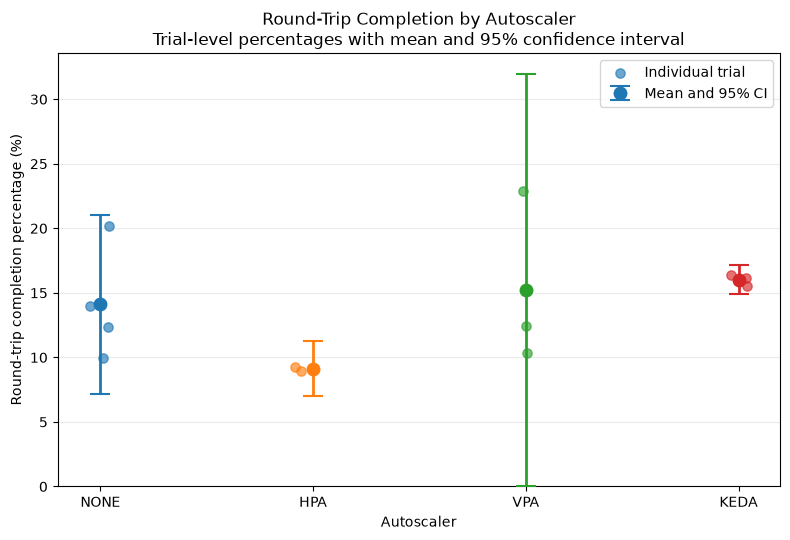

In [18]:
fig, ax = plot_roundtrip_completion_by_autoscaler(
    merged_trial_summary_df,
    autoscaler_order=["none", "hpa", "vpa", "keda"],
)

plt.show()

In [19]:
fig.savefig(
    "../figures/roundtrip_completion_by_autoscaler.png",
    dpi=300,
    bbox_inches="tight",
)

## Calculate $\theta$

In [96]:
TIME_SLICE_SECONDS = 30
raw_df = df.copy()

raw_df = append_time_slice(raw_df, time_slice_seconds=TIME_SLICE_SECONDS)
theta_results = calculate_theta_metrics(raw_df)
weighted_theta_results = add_weighted_theta(
    theta_results.autoscalers,
    gamma=0.50,
    omega=0.50,
)
weighted_theta_results




min_start = 0 days 00:00:00
max_start = 0 days 08:39:49.401701


NameError: name 'TIME_SLICE_SECONDS' is not defined

## Calculate $\tau$

In [93]:
TIME_SLICE_SECONDS = 30
raw_df = df.copy()

raw_df = append_time_slice(raw_df, time_slice_seconds=TIME_SLICE_SECONDS)
tau_results = calculate_tau_metrics(raw_df)
display(tau_results.autoscalers)

weighted_tau_results = add_weighted_tau(
    tau_results.autoscalers,
    gamma=0.50,
    omega=0.50,
)
weighted_tau_results



min_start = 0 days 00:00:00
max_start = 0 days 08:39:49.401701


,autoscaler,tau_u_rt_mean,tau_u_rt_std,tau_u_rt_count,tau_o_rt_mean,tau_o_rt_std,tau_o_rt_count,tau_u_fr_mean,tau_u_fr_std,tau_u_fr_count,tau_o_fr_mean,tau_o_fr_std,tau_o_fr_count,tau_u_rt_sem,tau_o_rt_sem,tau_u_fr_sem,tau_o_fr_sem
0,hpa,37.096774,11.404948,2,62.903226,11.404948,2,16.129032,13.685938,2,83.870968,13.685938,2,8.064516,8.064516,9.677419,9.677419
1,keda,36.559140,13.036942,3,63.440860,13.036942,3,8.602151,12.212706,3,91.397849,12.212706,3,7.526882,7.526882,7.051009,7.051009
2,none,42.231183,12.988184,4,57.768817,12.988184,4,30.053763,22.203976,4,69.946237,22.203976,4,6.494092,6.494092,11.101988,11.101988
3,vpa,49.462366,13.036942,3,50.537634,13.036942,3,36.559140,24.637504,3,63.440860,24.637504,3,7.526882,7.526882,14.224469,14.224469


,autoscaler,tau_u_rt_mean,tau_u_rt_std,tau_u_rt_count,tau_o_rt_mean,tau_o_rt_std,tau_o_rt_count,tau_u_fr_mean,tau_u_fr_std,tau_u_fr_count,tau_o_fr_mean,tau_o_fr_std,tau_o_fr_count,tau_u_rt_sem,tau_o_rt_sem,tau_u_fr_sem,tau_o_fr_sem,tau_rt_mean,tau_fr_mean,tau_mean
0,hpa,37.096774,11.404948,2,62.903226,11.404948,2,16.129032,13.685938,2,83.870968,13.685938,2,8.064516,8.064516,9.677419,9.677419,50.0,50.0,50.0
1,keda,36.559140,13.036942,3,63.440860,13.036942,3,8.602151,12.212706,3,91.397849,12.212706,3,7.526882,7.526882,7.051009,7.051009,50.0,50.0,50.0
2,none,42.231183,12.988184,4,57.768817,12.988184,4,30.053763,22.203976,4,69.946237,22.203976,4,6.494092,6.494092,11.101988,11.101988,50.0,50.0,50.0
3,vpa,49.462366,13.036942,3,50.537634,13.036942,3,36.559140,24.637504,3,63.440860,24.637504,3,7.526882,7.526882,14.224469,14.224469,50.0,50.0,50.0
